In [1]:
"""
This dataset provides a simple time series to demonstrate different visualization methods.
Enhanced with timesmith and plotsmith for streamlined time series operations and visualizations.
"""

import pandas as pd
import numpy as np
import timesmith as ts
import plotsmith as ps

np.random.seed(42)
time = pd.date_range(start="2023-01-01", periods=100, freq="D")
data = {
    "Date": time,
    "Value": 100 + 2 * np.arange(100) + np.sin(np.linspace(0, 10, 100)) * 10 + np.random.normal(0, 5, 100),
}
df = pd.DataFrame(data)
df.set_index("Date", inplace=True)  # Set Date as index for timesmith compatibility



tslearn not installed. DTW distance will use fallback implementation. Install with: pip install tslearn for optimized DTW.


ruptures library not installed. PELT functionality will be limited. Install with: pip install ruptures


PyWavelets not available. Wavelet functionality will be unavailable. Install with: pip install PyWavelets


pmdarima not installed. ARIMAForecaster will not work. Install with: pip install pmdarima


/Users/kylejonespatricia/Downloads/2025-11-05_ipynb_processed/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


darts not installed. LSTMForecaster will not work. Install with: pip install darts


filterpy not installed. KalmanFilterForecaster will not work. Install with: pip install filterpy


PyMC not available. BayesianForecaster requires PyMC. Install with: pip install pymc arviz


## Line Plot with Moving Average

A moving average smooths short-term fluctuations, revealing the underlying trend. 
In this example, we use timesmith's RollingFeaturizer to calculate a 7-day moving average 
and plotsmith to visualize it alongside the original time series.


(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Time Series with Moving Average'}, xlabel='Date', ylabel='Value'>)

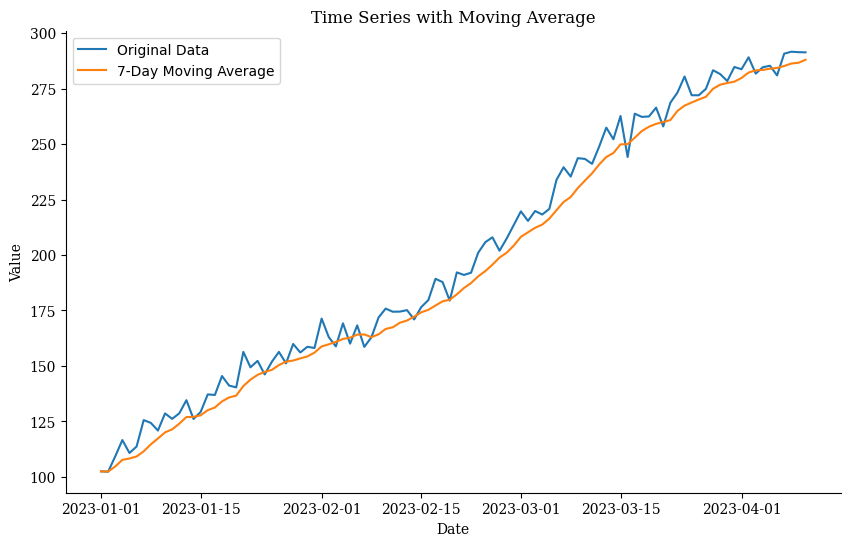

In [2]:
# Use timesmith's RollingFeaturizer to calculate moving average
# RollingFeaturizer adds enhanced rolling statistics to pandas
rolling_feat = ts.RollingFeaturizer(windows=[7], functions=['mean'])
rolling_features = rolling_feat.fit_transform(df[["Value"]])
df["Moving_Avg"] = rolling_features["rolling_mean_7"]  # Extract the 7-day mean

# Use plotsmith for enhanced time series visualization
# Ensure the DataFrame has the datetime index preserved
plot_df = pd.DataFrame({
    "Original Data": df["Value"],
    "7-Day Moving Average": df["Moving_Avg"]
}, index=df.index)

ps.plot_timeseries(
    plot_df,
    title="Time Series with Moving Average",
    xlabel="Date",
    ylabel="Value",
    figsize=(10, 6)
)


## Seasonal Decomposition

Decompose the time series into trend, seasonal, and residual components using statsmodels.
We use plotsmith to visualize each component with consistent styling.

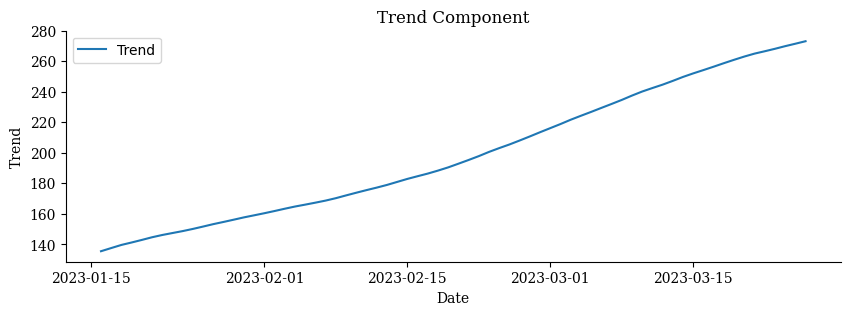

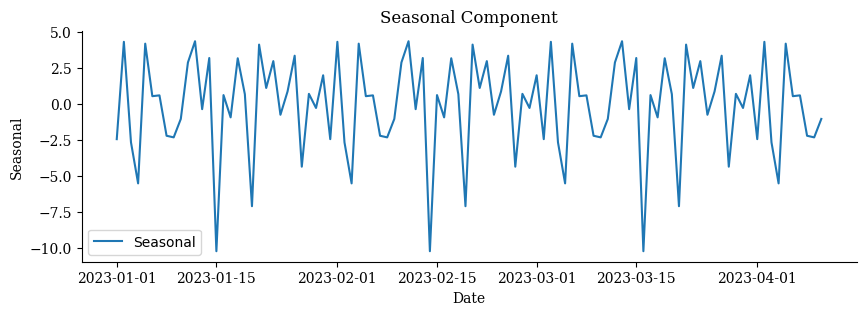

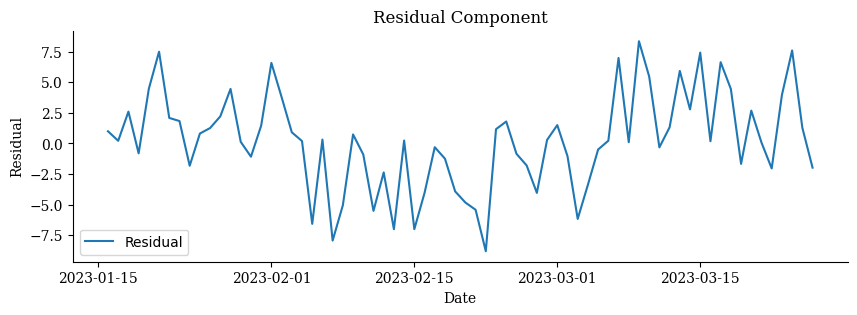

In [3]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposed = seasonal_decompose(df["Value"], period=30, model="additive")

# Use plotsmith to visualize each component
# Ensure the DataFrame has the datetime index preserved
decomp_df = pd.DataFrame({
    "Trend": decomposed.trend,
    "Seasonal": decomposed.seasonal,
    "Residual": decomposed.resid
}, index=df.index)

# Plot each component separately with plotsmith
for component in ["Trend", "Seasonal", "Residual"]:
    ps.plot_timeseries(
        decomp_df[[component]],
        title=f"{component} Component",
        xlabel="Date",
        ylabel=component,
        figsize=(10, 3)
    )


## Heatmap Visualization

Create a heatmap showing average values by day of week and month using plotsmith's enhanced heatmap functionality.

(<Figure size 1000x600 with 2 Axes>,
 <Axes: title={'center': 'Heatmap of Daily Values'}, xlabel='Month', ylabel='Day of Week'>)

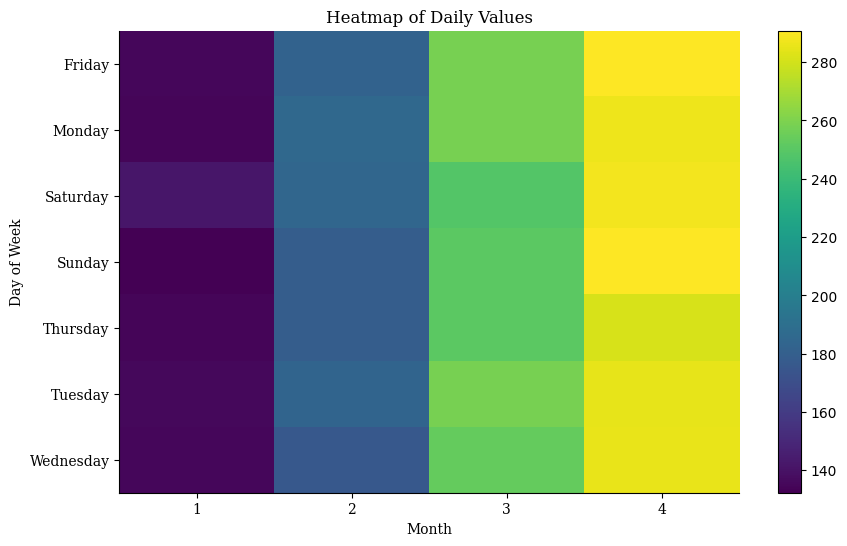

In [4]:
# Prepare data for heatmap
df_reset = df.reset_index()
df_reset["Day_of_Week"] = df_reset["Date"].dt.day_name()
df_reset["Month"] = df_reset["Date"].dt.month
pivot_table = df_reset.pivot_table(values="Value", index="Day_of_Week", columns="Month", aggfunc="mean")

# Use plotsmith's plot_heatmap for enhanced visualization
ps.plot_heatmap(
    pivot_table,
    title="Heatmap of Daily Values",
    xlabel="Month",
    ylabel="Day of Week",
    figsize=(10, 6)
)


## Multiple Time Series

Visualize multiple time series on the same plot using plotsmith's enhanced multi-series visualization.

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Multiple Time Series Comparison'}, xlabel='Date', ylabel='Value'>)

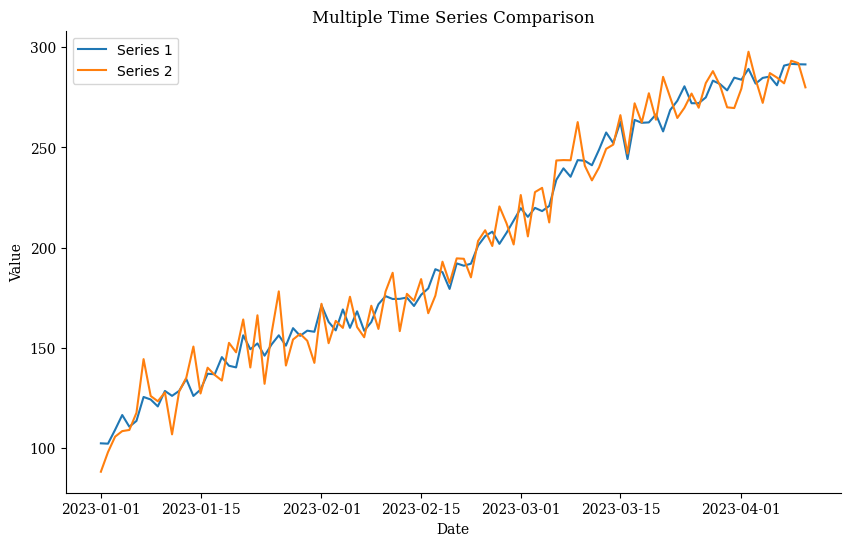

In [5]:
# Create a second series
df["Value_2"] = df["Value"] + np.random.normal(loc=0, scale=10, size=len(df))

# Use plotsmith to plot multiple series together
# Ensure the DataFrame has the datetime index preserved
multi_series_df = pd.DataFrame({
    "Series 1": df["Value"],
    "Series 2": df["Value_2"]
}, index=df.index)

ps.plot_timeseries(
    multi_series_df,
    title="Multiple Time Series Comparison",
    xlabel="Date",
    ylabel="Value",
    figsize=(10, 6)
)


## Interactive Visualizations with Plotly

For interactive plots with zooming, panning, and annotations, we use Plotly alongside plotsmith.
plotsmith complements pandas and works well with other visualization libraries.

In [6]:
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Scatter(x=df.index, y=df["Value"], mode="lines", name="Value"))
fig.add_annotation(
    x=df.index[50],
    y=df["Value"].iloc[50],
    text="Notable Point",
    showarrow=True,
    arrowhead=1,
)
fig.update_layout(title="Interactive Line Plot", xaxis_title="Date", yaxis_title="Value")
fig.show()


In [7]:
# Dual axis plot with Plotly
fig = go.Figure()
fig.add_trace(go.Scatter(x=df.index, y=df["Value"], name="Series 1", yaxis="y1"))
fig.add_trace(go.Scatter(x=df.index, y=df["Value_2"], name="Series 2", yaxis="y2"))
fig.update_layout(
    title="Dual Axis Plot",
    xaxis=dict(title="Date"),
    yaxis=dict(title="Series 1", side="left"),
    yaxis2=dict(title="Series 2", overlaying="y", side="right"),
)
fig.show()

In [8]:
# Time series with range slider for interactive zooming
fig = go.Figure()
fig.add_trace(go.Scatter(x=df.index, y=df["Value"], mode="lines", name="Value"))
fig.update_layout(
    title="Time Series with Range Slider",
    xaxis=dict(
        rangeslider=dict(visible=True),
        type="date"
    )
)
fig.show()

## Summary: What timesmith and plotsmith Added

### Enhancements:
- **RollingFeaturizer**: Easy calculation of moving averages with unified API
- **Enhanced Time Series Visualization**: `plotsmith.plot_timeseries()` provides cleaner, more consistent plots
- **Heatmap Visualization**: `plotsmith.plot_heatmap()` for enhanced heatmap functionality
- **Pandas Integration**: All operations work seamlessly with pandas DataFrames and Series

### Key Benefits:
1. **Simplified Moving Averages**: RollingFeaturizer makes it easy to calculate rolling statistics
2. **Better Plots**: plotsmith handles styling and formatting automatically
3. **Consistent Patterns**: Same API patterns across all visualization operations
4. **Enhanced Analysis**: timesmith and plotsmith extend pandas with time series-specific features
5. **Flexible Integration**: Works alongside matplotlib, seaborn, and plotly for specialized needs
